In [1]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336')
import jax
jax.config.update("jax_enable_x64", True)
#jax.config.update('jax_platform_name', 'cpu')
#jax.config.update('jax_num_cpu_devices', 6)
import scipy.constants as C
import jax.numpy as jnp
from EM_analyzer.Spectral_Maxwell.Normal_variable_method import Spectral_Maxwell_Solver_2D
from plot.plot_2D import plot_2D_field

Backend: GPU, local device count: 2
[CudaDevice(id=0), CudaDevice(id=1)]


In [2]:
laser_lambda=800*C.micron

In [3]:
Nx=4000
Ny=2000
Lx=20*laser_lambda
Ly=10*laser_lambda
dx=Lx/Nx
dy=Ly/Ny
x_coordinate=jnp.linspace(-Lx/2, Lx/2, Nx,endpoint=False)+dx/2
y_coordinate=jnp.linspace(-Ly/2, Ly/2, Ny,endpoint=False)+dy/2
x,y=jnp.meshgrid(x_coordinate,y_coordinate,indexing='ij')


In [4]:
Ey=jnp.ones((Nx,Ny))*(jnp.abs(x)<2*laser_lambda)*(jnp.abs(y)<3*laser_lambda)*jnp.cos(2*jnp.pi*x/laser_lambda)
Bz=Ey/C.speed_of_light

figure size= [26.5 14. ] inch
ax_main position= Bbox(x0=0.16981132075471697, y0=0.10714285714285714, x1=0.7735849056603773, y1=0.6785714285714285)


{'fig': <Figure size 2650x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='x/λ', ylabel='y/λ'>,
 'ax_panel_top': <Axes: xlabel='x/λ', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='y/λ'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x154c7c269be0>}

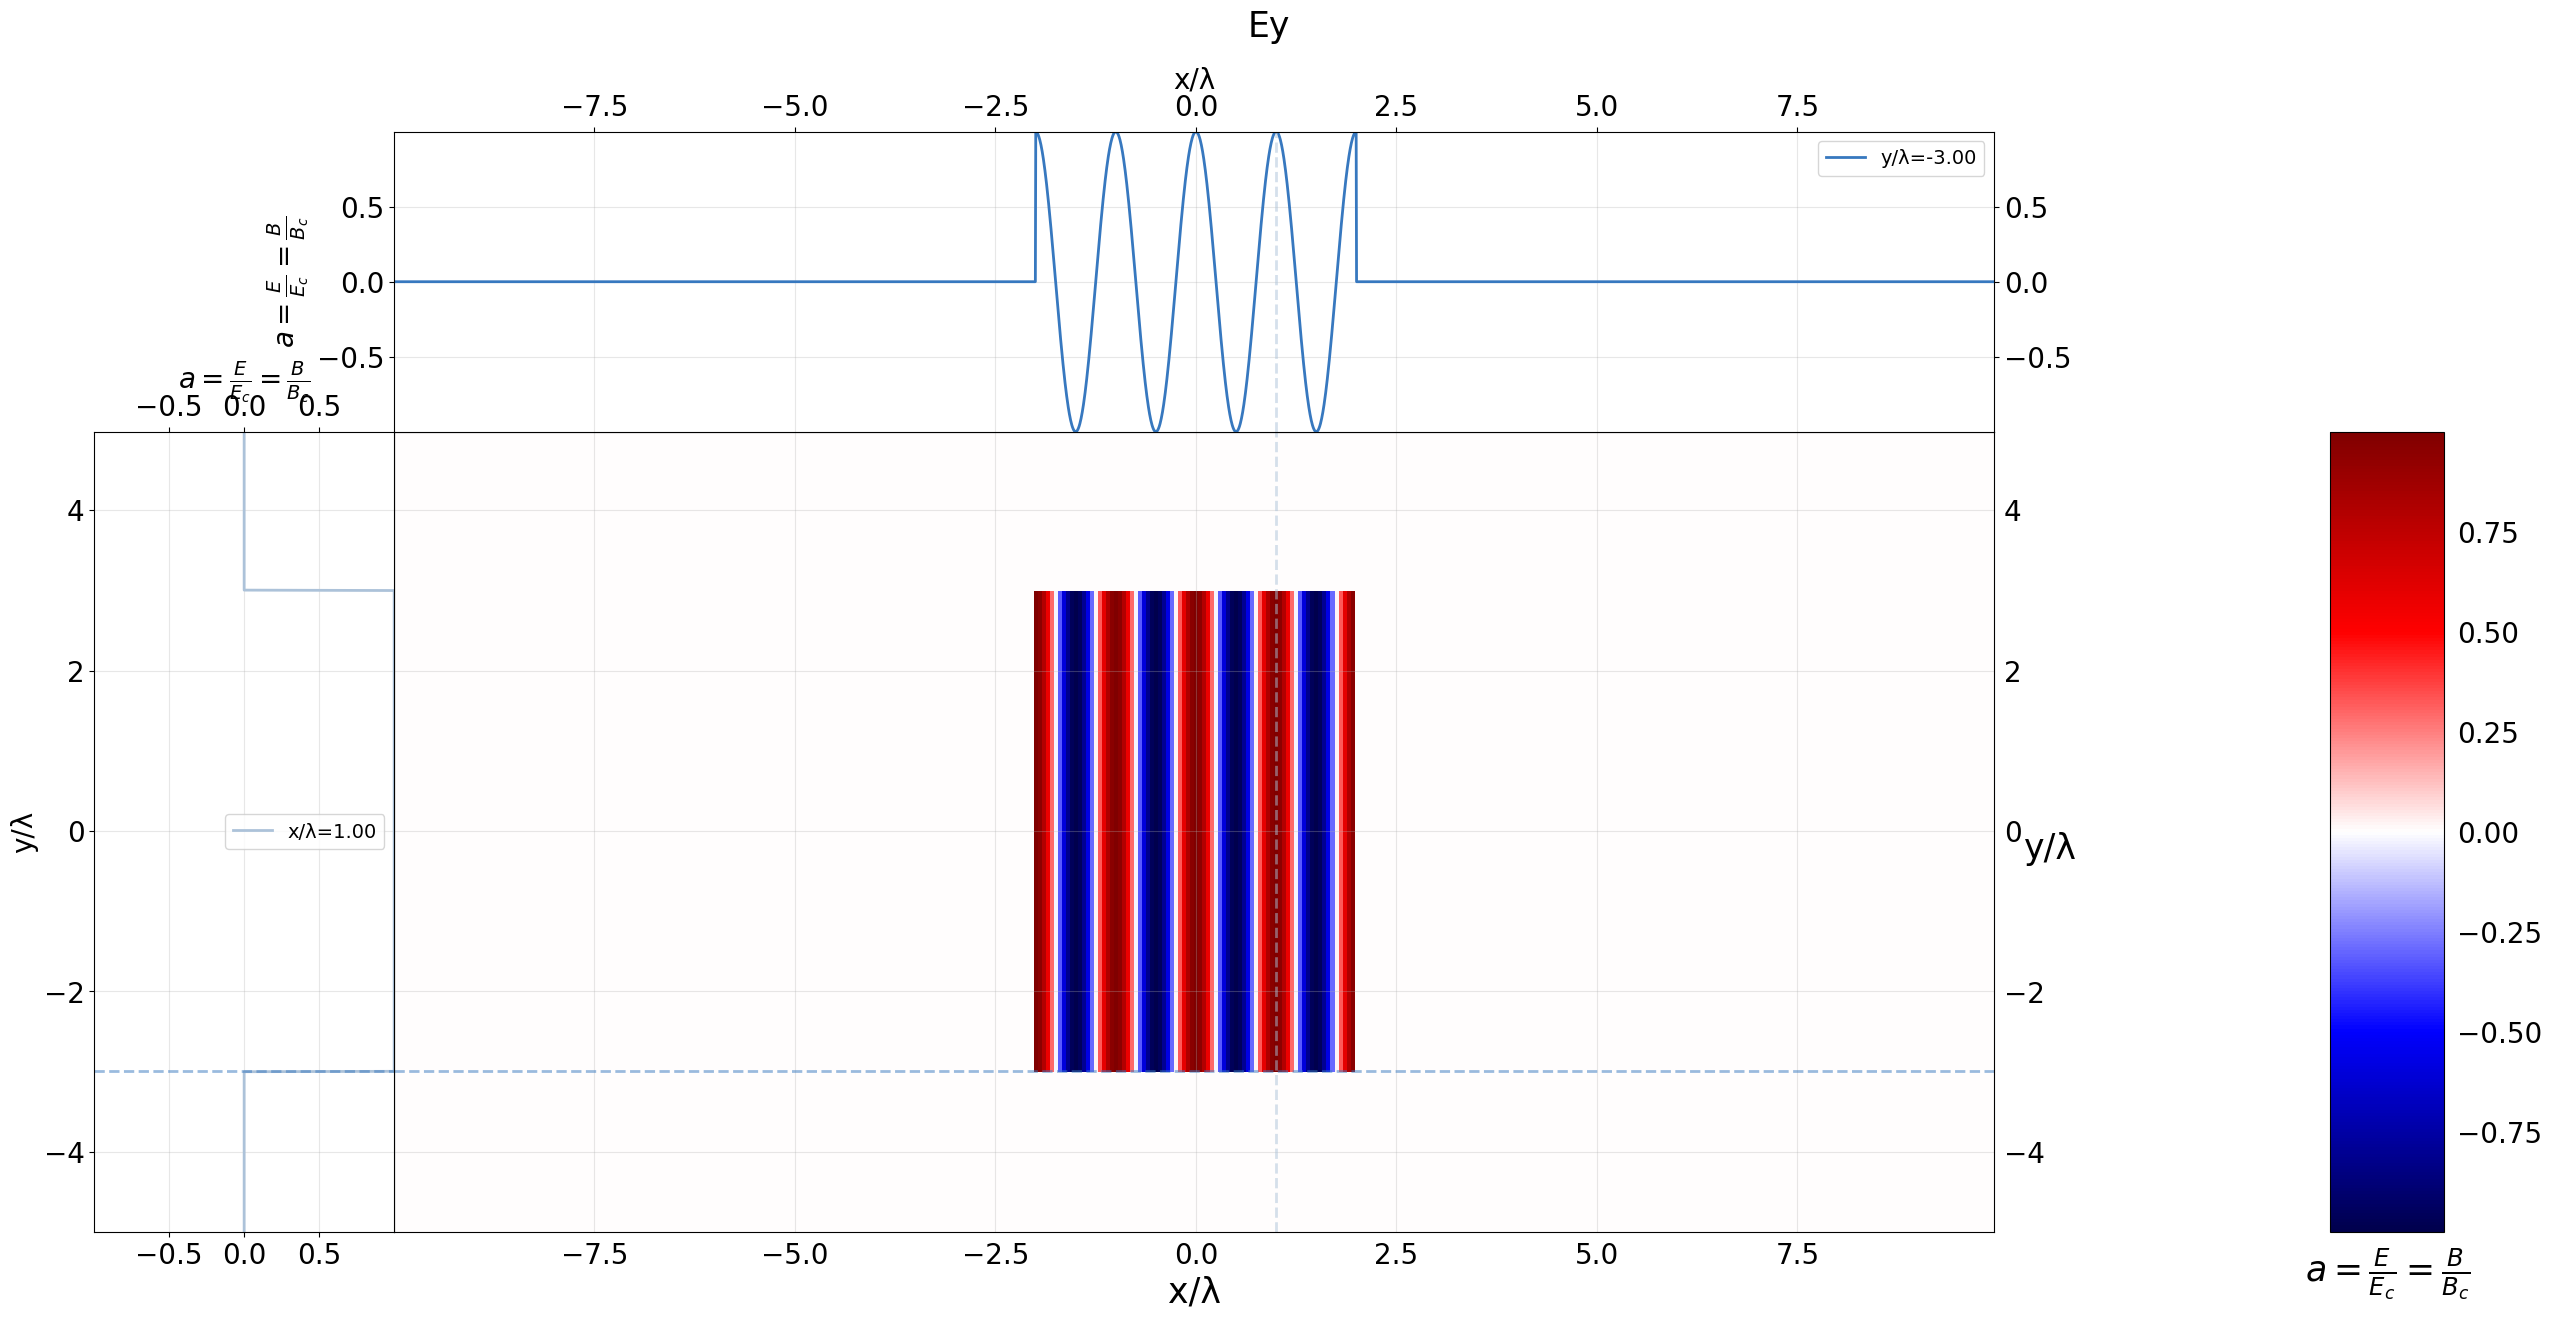

In [5]:
plot_2D_field(
    field=Ey,x_coordinate=x_coordinate/laser_lambda,y_coordinate=y_coordinate/laser_lambda,xlabel='x/λ',ylabel='y/λ',
    step_x=10,step_y=5,
    name='Ey'
    )

In [6]:
Solver=Spectral_Maxwell_Solver_2D(
    E0y=Ey,
    B0z=Bz,
    x_coordinate=x_coordinate,
    y_coordinate=y_coordinate,
)

Stacked field shape: (3, 4000, 2000, 1)
Stacked field shape: (3, 4000, 2000, 1)
Initial field shapes (3, 4000, 2000, 1) verified.
Initial field shapes (3, 4000, 2000, 1) verified.
Max relative divergence error: L*|∇·F|/|F| = 1.25e-01
Initial Field divergence check passed: relative L*|∇·F|/|F| = 0.12500000000002406 <= 0.5
Max relative divergence error: L*|∇·F|/|F| = 0.00e+00
Initial Field divergence check passed: relative L*|∇·F|/|F| = 0.0 <= 0.5
Pad widths for each axis: [(0, 0), (0, 0), (2008, 2008), (1008, 1008), (0, 0)]
Input shape: (2, 3, 4000, 2000, 1)
Output padded shape: (2, 3, 8016, 4016, 1)


W0617 17:09:38.129692 2576036 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 11.74GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
E0617 17:09:38.129774 2576036 cuda_fft.cc:272] Failed to allocate work area.
E0617 17:09:38.129807 2576036 cuda_fft.cc:323] Initialize Params: rank: 3 elem_count: 8016 input_embed: 8016 input_stride: 1 input_distance: 32192256 output_embed: 8016 output_stride: 1 output_distance: 32192256 batch_count: 6
E0617 17:09:38.129816 2576036 cuda_fft.cc:332] Failed to initialize batched cufft plan with customized allocator: Out of memory while trying to allocate 11.74GiB.
W0617 17:09:38.136501 2576039 bfc_allocator.cc:311] Allocator (GPU_1_bfc) ran out of memory trying to allocate 11.74GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if mor

╭──────── Initial spectrum from field ────────╮
│ shape: (2, 3, 8016, 4016, 1)                │
│ dtype: complex128                           │
│ size: 2.9 GiB                               │
│ NamedSharding: P('EM', None)                │
│ axis 0 is sharded: GPU 0 contains 0:1 (1/2) │
│                    Total size: 2            │
╰─────────────────────────────────────────────╯

Padded field shapes (2, 3, 8016, 4016, 1) verified.
k-space grid shapes (3, 8016, 4016, 1) verified.
Transversality enforced in k-space.


W0617 17:09:39.079762 2575352 hlo_rematerialization.cc:3233] Can't reduce memory use below 8.79GiB (9439003482 bytes) by rematerialization; only reduced to 12.47GiB (13391978528 bytes), down from 12.47GiB (13391978528 bytes) originally


In [7]:
evolution_dict=Solver.evolution(evolution_time=2*laser_lambda/C.speed_of_light,window_shift_velocity=(C.speed_of_light,0))

Evolution time: 5.337025523170432e-12 s, window shift velocity: [2.99792458e+08 0.00000000e+00 0.00000000e+00] m/s


JaxRuntimeError: INTERNAL: RET_CHECK failure (external/xla/xla/backends/gpu/runtime/fft_thunk.cc:199) fft_plan != nullptr Failed to create cuFFT batched plan with scratch allocator

figure size= [26.5 14. ] inch
ax_main position= Bbox(x0=0.16981132075471697, y0=0.10714285714285714, x1=0.7735849056603773, y1=0.6785714285714285)


{'fig': <Figure size 2650x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='x/λ', ylabel='y/λ'>,
 'ax_panel_top': <Axes: xlabel='x/λ', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='y/λ'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14f9a83b9f30>}

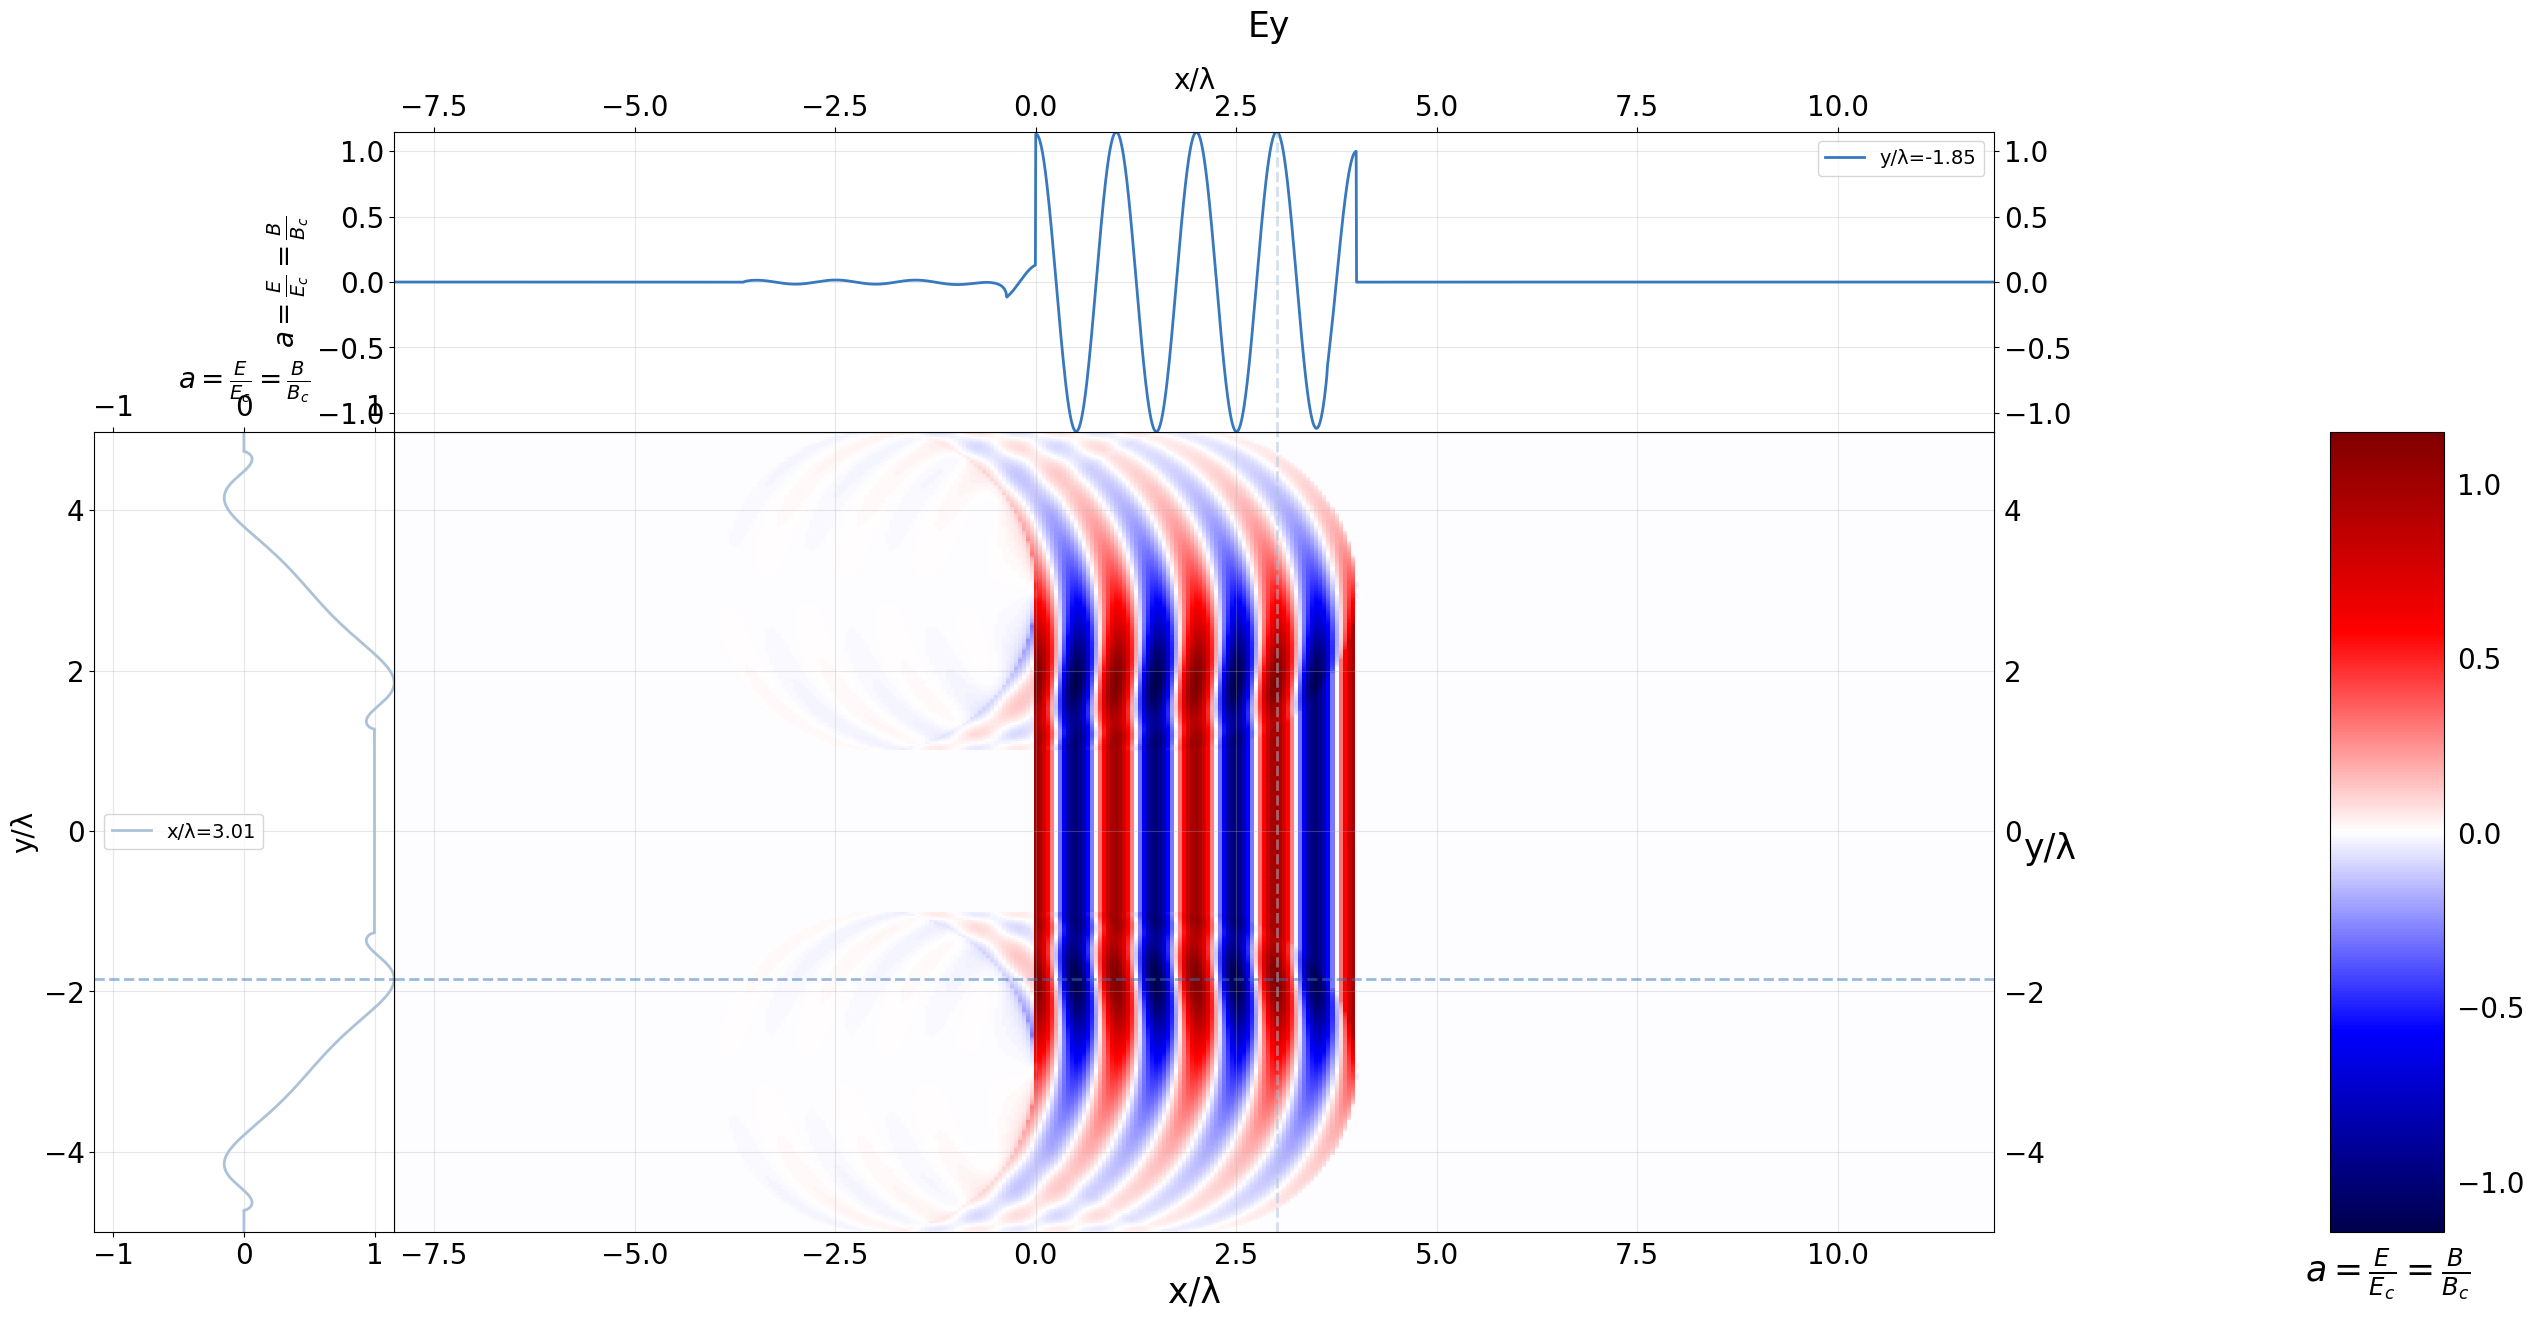

In [15]:
plot_2D_field(
    field=evolution_dict['Ey'],
    x_coordinate=evolution_dict['x_coordinate']/laser_lambda,y_coordinate=evolution_dict['y_coordinate']/laser_lambda,xlabel='x/λ',ylabel='y/λ',
    step_x=10,step_y=5,
    name='Ey'
    )